# Federated counterparty-risk forecasting with `esnfed`

This tutorial walks through the headline use case of **esnfed**, a federated
reservoir-computing toolkit: several financial institutions jointly forecast a
**counterparty-risk** signal *without sharing their raw data*.

We use the **TED spread** — the gap between the 3-month interbank rate and the
3-month Treasury bill — a classic gauge of perceived counterparty/credit risk
in the banking system. A series is bundled with the package (source: FRED,
`TEDRATE`).

**What you'll see**
1. Load and visualise the TED spread.
2. Train a single Echo State Network (ESN) and forecast the spread.
3. Federate across institutions with **exact federated ridge** — and watch
   naive **local-only** training collapse.
4. (Optional) design a reservoir in **ReservoirPy** and federate it here.
5. (Optional) run the same scheme through the **Flower** FL framework.

Install with: `pip install "esnfed[experiments,reservoirpy,flower]"`

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from esnfed import EchoStateNetwork, datasets, federated, topologies, metrics

RNG = 0
plt.rcParams.update({"figure.figsize": (9, 3.5), "axes.grid": True,
                     "grid.alpha": 0.3})

## 1. The data: a counterparty-risk time series

`load_ted_spread(raw=True)` returns the raw daily spread (in percentage
points). Notice the dramatic spike during the 2007–2009 financial crisis —
exactly when counterparty risk exploded.

8853 daily observations, range 0.06 to 4.58 pp


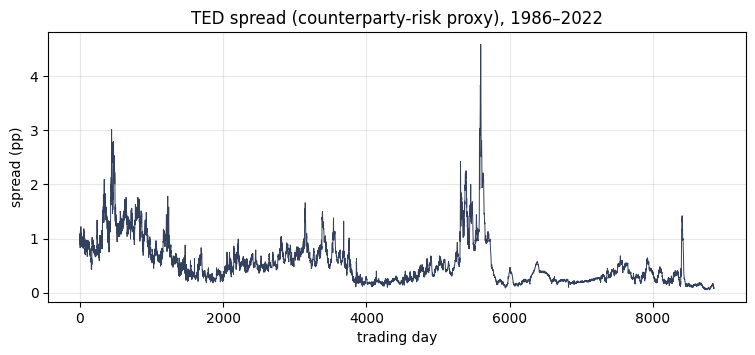

In [2]:
raw = datasets.load_ted_spread(raw=True)
print(f"{len(raw)} daily observations, range {raw.min():.2f} to {raw.max():.2f} pp")

fig, ax = plt.subplots()
ax.plot(raw, lw=0.7, color="#33415c")
ax.set_title("TED spread (counterparty-risk proxy), 1986–2022")
ax.set_xlabel("trading day")
ax.set_ylabel("spread (pp)")
plt.show()

For modelling we use the normalised one-step-ahead forecasting task: given the
spread today, predict it tomorrow. `load_ted_spread()` returns `(u, y)` ready
to use.

In [3]:
u, y = datasets.load_ted_spread()           # normalised, one-step-ahead
u_tr, y_tr, u_te, y_te = datasets.split(u, y, train_frac=0.7)
print("train:", u_tr.shape, " test:", u_te.shape)

train: (6196, 1)  test: (2656, 1)


## 2. A single Echo State Network

An ESN has a large, fixed, random *reservoir* and a single trained linear
*readout*. Training is a one-shot ridge regression — no backprop — so it is
fast and cheap, which is ideal for the edge and for federation.

single-ESN test NRMSE: 0.413  (trivial predictor = 1.0)


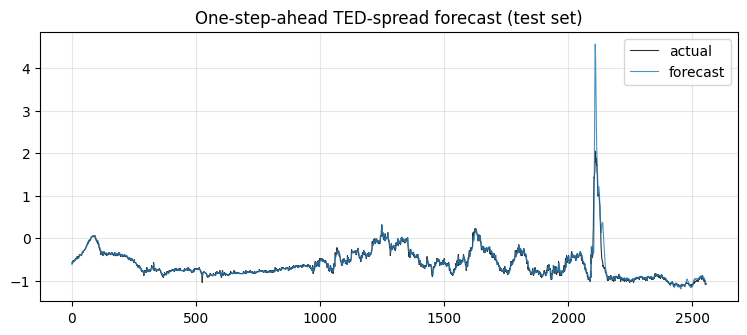

In [4]:
W = topologies.random_reservoir(200, density=0.1, rng=RNG)
esn = EchoStateNetwork(1, 1, W, spectral_radius=0.9, leaking_rate=0.5,
                       washout=100, ridge=1e-6)
esn.fit(u_tr, y_tr)
pred = esn.predict(u_te)

wo = esn.washout
nrmse_single = metrics.nrmse(y_te[wo:], pred[wo:])
print(f"single-ESN test NRMSE: {nrmse_single:.3f}  (trivial predictor = 1.0)")

fig, ax = plt.subplots()
ax.plot(y_te[wo:], color="#333", lw=0.8, label="actual")
ax.plot(pred[wo:], color="#1f77b4", lw=0.8, alpha=0.8, label="forecast")
ax.set_title("One-step-ahead TED-spread forecast (test set)")
ax.legend()
plt.show()

### Look inside the ESN with `esnfed.viz`

Four quick views. Plotly is the default backend (interactive); here we pass
`backend="matplotlib"` so the images render inline on GitHub. The spectrum plot
shows all eigenvalues inside the unit circle — the **echo state property** holds.

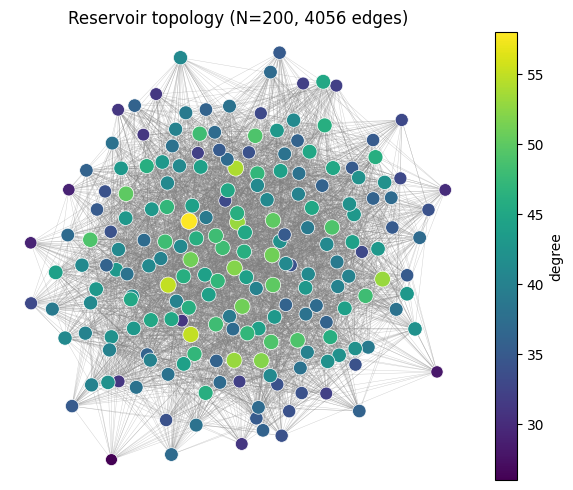

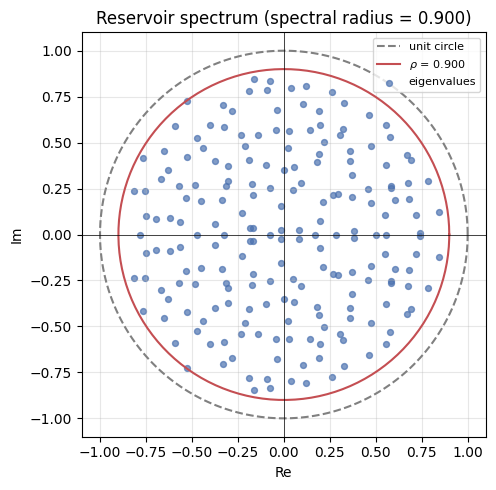

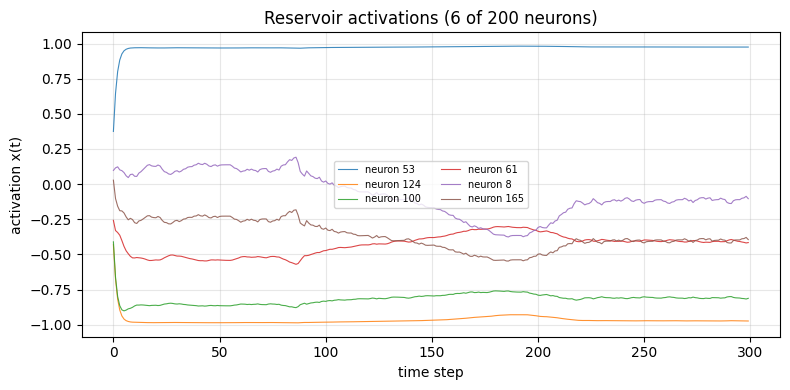

In [5]:
from esnfed import viz

_ = viz.plot_reservoir(esn, backend="matplotlib")       # connectivity graph
_ = viz.plot_spectrum(esn, backend="matplotlib")        # eigenvalues + unit circle
_ = viz.plot_states(esn, u_te, n_neurons=6, backend="matplotlib")  # the "echoes"

## 3. The federated setting

Now imagine the training history is split across **institutions** that cannot
pool their data. We give each a contiguous time slice.

In [6]:
N_INSTITUTIONS = 10
parts = datasets.partition_iid(u_tr, y_tr, N_INSTITUTIONS, rng=RNG)
print(f"{len(parts)} institutions; samples each:",
      [len(p[0]) for p in parts])

10 institutions; samples each: [619, 620, 619, 620, 620, 619, 620, 619, 620, 620]


### Exact federated ridge

Each institution computes only the **sufficient statistics** of its local
ridge problem (`A_k = ZᵀZ`, `B_k = ZᵀY`) and sends those — never raw data.
The server sums them and solves once. The result is *mathematically identical*
to pooling all the data centrally.

In [7]:
esn_kw = dict(spectral_radius=0.9, leaking_rate=0.5, washout=100, ridge=1e-6)
clients, ref = federated.make_shared_clients(W, parts, input_seed=0,
                                             esn_kwargs=esn_kw)
W_out = federated.federated_ridge(clients, ref)

Z_test = ref.harvest(u_te)[ref.washout:]
nrmse_fed = metrics.nrmse(y_te[ref.washout:], Z_test @ W_out)
print(f"federated-ridge test NRMSE: {nrmse_fed:.3f}")

federated-ridge test NRMSE: 0.328


### ...versus training locally and not collaborating

If each institution just trains on its own slice, the models overfit their
short, non-stationary period and **collapse** on the held-out future.

In [8]:
federated.train_local(clients)
local_errs = [metrics.nrmse(y_te[ref.washout:], c.esn.predict(u_te)[ref.washout:])
              for c in clients]
print(f"local-only test NRMSE: median {np.median(local_errs):.2f}, "
      f"worst {np.max(local_errs):.2f}")
print(f"\nfederated {nrmse_fed:.3f}  vs  local median {np.median(local_errs):.2f}"
      f"  ->  federation is essential here, and it is exact and private.")

local-only test NRMSE: median 12.69, worst 44.89

federated 0.328  vs  local median 12.69  ->  federation is essential here, and it is exact and private.


## 4. (Optional) Design the reservoir in ReservoirPy, federate it here

`esnfed` does not try to replace [ReservoirPy](https://reservoirpy.readthedocs.io)
for *building* reservoirs — it adds the *federated* layer. You can tune a
reservoir there and drop it straight into the federated strategies.

In [9]:
try:
    from reservoirpy.nodes import Reservoir
    from esnfed import interop

    res = Reservoir(200, sr=0.9, lr=0.5, input_dim=1)   # design in ReservoirPy
    W_rpy = interop.reservoir_matrix(res)               # extract its reservoir
    clients_rpy, ref_rpy = federated.make_shared_clients(
        W_rpy, parts, input_seed=0, esn_kwargs=esn_kw)
    W_out_rpy = federated.federated_ridge(clients_rpy, ref_rpy)
    Zt = ref_rpy.harvest(u_te)[ref_rpy.washout:]
    print("federated ReservoirPy reservoir, test NRMSE: "
          f"{metrics.nrmse(y_te[ref_rpy.washout:], Zt @ W_out_rpy):.3f}")
except ImportError:
    print("reservoirpy not installed - run: pip install 'esnfed[reservoirpy]'")

federated ReservoirPy reservoir, test NRMSE: 0.291


## 5. (Optional) The same scheme through Flower

The exact federated-ridge scheme maps onto [Flower](https://flower.ai): each
client's `fit` returns its sufficient statistics and a custom `Strategy` sums
them. See `examples/flower_federated_ridge.py`. The Flower-routed result equals
`federated_ridge` to numerical precision.

In [10]:
try:
    import importlib.util
    from pathlib import Path

    here = Path.cwd()
    ex = (here / "flower_federated_ridge.py")
    if not ex.exists():
        ex = here / "examples" / "flower_federated_ridge.py"
    spec = importlib.util.spec_from_file_location("flower_ex", ex)
    flower_ex = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(flower_ex)
    client_fns, strategy, (fl_clients, fl_ref, _, _) = flower_ex.build(
        n_clients=10, seed=RNG)
    W_flower, m = flower_ex.run_one_round(client_fns, strategy)
    # Compare against the direct scheme on the *same* clients (apples to apples).
    W_direct = federated.federated_ridge(fl_clients, fl_ref)
    print(f"Flower-routed test NRMSE: {m['nrmse']:.3f}  "
          f"(max |Flower - direct federated_ridge|: "
          f"{np.max(np.abs(W_flower - W_direct)):.1e})")
except Exception as e:  # noqa: BLE001 - optional dependency / path
    print(f"Flower example not run here ({type(e).__name__}); "
          "install with: pip install 'esnfed[flower]'")

Flower-routed test NRMSE: 0.330  (max |Flower - direct federated_ridge|: 0.0e+00)


## Takeaways

- **Reservoir computing + federated learning** is a natural fit: ESNs train in
  one shot, so federated training reduces to combining linear readouts.
- **Exact federated ridge** reproduces centralised accuracy in a single,
  privacy-preserving round — and on real, non-stationary financial data it is
  not just better than going it alone, it is *essential* (local models
  collapse).
- `esnfed` complements ReservoirPy and slots into Flower, so it fits existing
  workflows rather than replacing them.

Next steps: try `datasets.load_fred("BAMLH0A0HYM2")` for a high-yield credit
spread, or `datasets.from_array(my_series)` for your own data.